In [6]:
from NN_model_helper import (evaluate_fold_TL, set_freeze_mode, plot_training_progress, find_optimal_clusters)
from pathlib import Path
import sys
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import numpy as np
from NN_model import ImprovedNN 

In [7]:
df = pd.read_parquet("../Ro5/artifacts/final_dataset_RDKit_50_threshold_0_scaled.parquet")
df.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_NumHeteroatoms,RDKit_PEOE_VSA7,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_fr_priamide,RDKit_NumAliphaticRings,RDKit_fr_quatN,RDKit_fr_COO,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_SlogP_VSA4,RDKit_fr_allylic_oxid,RDKit_NHOHCount,RDKit_fr_ArN
0,c1ccc(cc1)n1cncc1,13.00,Train,1,0.382336,-0.882978,-0.693833,-0.772773,0.378189,-1.132235,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.536894,-0.306271,-0.656439,-0.209052,-0.862968,-0.270778
1,Fc1cccc(c1c1noc(c1C(=O)O)C)Cl,202.00,Train,1,1.210742,0.598113,-0.348357,-0.319828,-0.444076,0.879647,...,-0.156889,-0.506106,-0.037112,2.103004,-0.137966,-0.306271,0.656088,-0.209052,-0.074623,-0.270778
2,c1ccc2c(c1)non2,54.00,Train,1,1.177431,-0.512705,-0.179225,-0.989164,0.023560,-0.836178,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.491383,-0.306271,-0.656439,-0.209052,-0.862968,-0.270778
3,Cc1ccn[nH]c1=O,153.85,Train,1,-0.463529,-0.512705,-0.651052,-0.878915,-0.769099,0.259721,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.498306,-0.306271,0.056819,-0.209052,-0.074623,-0.270778
4,OCC12CCCC(C1CC(C13C2C(O)CC(C1O)C(C3=O)C)O)(C)CO,266.00,Train,1,-0.463529,0.598113,0.843072,0.099328,-0.995496,-0.731595,...,-0.156889,3.270771,-0.037112,-0.360850,2.644924,-0.306271,3.455622,-0.209052,3.078757,-0.270778


In [8]:
df_bro5 = df[
    (df["Type"] == "Train") &
    (df["Ro5"] == 0)
].copy()

print("Shape:", df_bro5.shape)
print(df_bro5[["Type", "Ro5"]].value_counts())

Shape: (1009, 76)
Type   Ro5
Train  0      1009
Name: count, dtype: int64


In [9]:
df_bro5.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_NumHeteroatoms,RDKit_PEOE_VSA7,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_fr_priamide,RDKit_NumAliphaticRings,RDKit_fr_quatN,RDKit_fr_COO,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_SlogP_VSA4,RDKit_fr_allylic_oxid,RDKit_NHOHCount,RDKit_fr_ArN
6,CCCCCCCc1ccc(cc1)c1ccc(cc1)C#N,31.00,Train,0,1.191337,-1.253251,0.779735,0.705258,1.552758,-1.132323,...,-0.156889,-0.506106,-0.037112,-0.36085,-1.107161,-0.306271,0.510851,-0.209052,-0.862968,-0.270778
8,CC(=O)OC1CC2C(=C)C(=O)C3(C1C14C(CCC(C4CC3OC1OC...,230.00,Train,0,-0.463529,2.079204,0.825868,0.724879,-0.995496,0.574788,...,-0.156889,5.159210,-0.037112,-0.36085,2.497138,-0.306271,2.845981,-0.209052,-0.862968,-0.270778
34,O=CC[C@H]1C[C@@H](C)[C@@H](O)/C=C/C=C/C[C@H](O...,131.50,Train,0,-0.463529,4.300841,1.992245,5.011465,-1.101778,0.616167,...,-0.156889,2.326552,-0.037112,-0.36085,7.901523,-0.306271,1.172484,2.120960,1.502067,-0.270778
36,Clc1ccc(cc1)Sc1nc(=N)[nH]c(c1c1ccccc1)N1CCCCC1,188.85,Train,0,1.191337,0.598113,1.150305,0.534808,1.459709,-0.115911,...,-0.156889,0.438113,-0.037112,-0.36085,0.269533,-0.306271,-0.099195,-0.209052,0.713722,-0.270778
41,BrC(C(c1ccccc1)Br)CCC(C(c1ccccc1)Br)Br,194.00,Train,0,-0.463529,-0.142432,-0.103257,1.391535,1.871613,-1.524125,...,-0.156889,-0.506106,-0.037112,-0.36085,-0.530728,-0.306271,-0.656439,-0.209052,-0.862968,-0.270778


X_scaled shape: (1009, 72)
Num features: 72


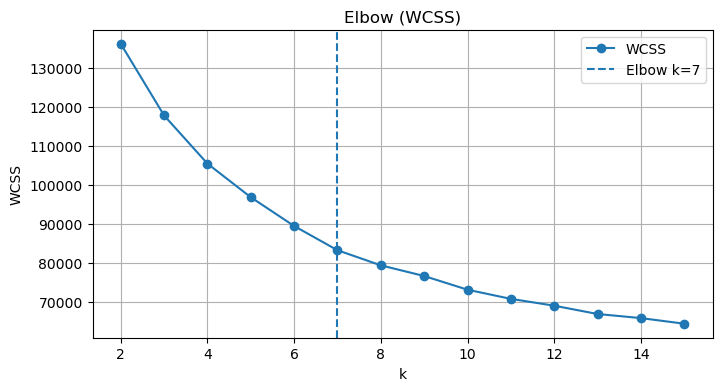

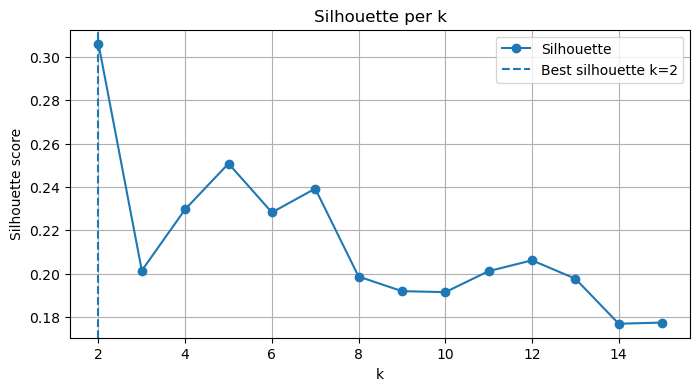

Elbow k: 7 | Best silhouette k: 2 | Selected k_opt: 7


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

BASE = Path.cwd()
artifacts_dir = BASE / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)


# 2) Define feature columns (already scaled), Exclude metadata/labels/non-features

exclude = {"SMILES", "MP", "Type", "Ro5"}
num_cols = df_bro5.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X_scaled = df_bro5[feature_cols].to_numpy(dtype=np.float32)

print("X_scaled shape:", X_scaled.shape)
print("Num features:", len(feature_cols))


# 3) Find optimal k

random_state = 0
k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)

if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")


# 4) Fit final kmeans + assign clusters

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_bro5), "Cluster labels length != df rows (mismatch)."

df_clustered = df_bro5.copy()
df_clustered["Structure_Cluster"] = cluster_labels


In [11]:
df_clustered.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_NumHeteroatoms,RDKit_PEOE_VSA7,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_NumAliphaticRings,RDKit_fr_quatN,RDKit_fr_COO,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_SlogP_VSA4,RDKit_fr_allylic_oxid,RDKit_NHOHCount,RDKit_fr_ArN,Structure_Cluster
6,CCCCCCCc1ccc(cc1)c1ccc(cc1)C#N,31.00,Train,0,1.191337,-1.253251,0.779735,0.705258,1.552758,-1.132323,...,-0.506106,-0.037112,-0.36085,-1.107161,-0.306271,0.510851,-0.209052,-0.862968,-0.270778,5
8,CC(=O)OC1CC2C(=C)C(=O)C3(C1C14C(CCC(C4CC3OC1OC...,230.00,Train,0,-0.463529,2.079204,0.825868,0.724879,-0.995496,0.574788,...,5.159210,-0.037112,-0.36085,2.497138,-0.306271,2.845981,-0.209052,-0.862968,-0.270778,6
34,O=CC[C@H]1C[C@@H](C)[C@@H](O)/C=C/C=C/C[C@H](O...,131.50,Train,0,-0.463529,4.300841,1.992245,5.011465,-1.101778,0.616167,...,2.326552,-0.037112,-0.36085,7.901523,-0.306271,1.172484,2.120960,1.502067,-0.270778,6
36,Clc1ccc(cc1)Sc1nc(=N)[nH]c(c1c1ccccc1)N1CCCCC1,188.85,Train,0,1.191337,0.598113,1.150305,0.534808,1.459709,-0.115911,...,0.438113,-0.037112,-0.36085,0.269533,-0.306271,-0.099195,-0.209052,0.713722,-0.270778,5
41,BrC(C(c1ccccc1)Br)CCC(C(c1ccccc1)Br)Br,194.00,Train,0,-0.463529,-0.142432,-0.103257,1.391535,1.871613,-1.524125,...,-0.506106,-0.037112,-0.36085,-0.530728,-0.306271,-0.656439,-0.209052,-0.862968,-0.270778,0


In [12]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "Ro5", "Structure_Cluster"}
num_cols = df_clustered.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_clustered[feature_cols].to_numpy(np.float32) 
y = df_clustered[TARGET_COL].to_numpy(np.float32)
y_strat = df_clustered["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 1009
Num features: 72
Num folds: 10

Fold  0 | Train:  908 | Val:  101
Fold  1 | Train:  908 | Val:  101
Fold  2 | Train:  908 | Val:  101
Fold  3 | Train:  908 | Val:  101
Fold  4 | Train:  908 | Val:  101
Fold  5 | Train:  908 | Val:  101
Fold  6 | Train:  908 | Val:  101
Fold  7 | Train:  908 | Val:  101
Fold  8 | Train:  908 | Val:  101
Fold  9 | Train:  909 | Val:  100


In [13]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd, torch, optuna

BASELINE_CKPT = Path("artifacts/general_best_Ro5_RDKit_50_threshold_0/general_best_fold_7.pt")

# --- scenarios: name, vector (for your notes), freeze_level used by evaluate_fold_TL ---

HIDDEN_LAYERS = [256, 128, 64]   # must match baseline arch
N_TRIALS      = 20

OUT_ROOT = Path("artifacts/TL_Ro5_only_RDKit_50_threshold_0")   # under the artifacts folder
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def run_one_scenario(tag, freeze_vec, freeze_level):
    print(f"\n=== Scenario: {tag} | freeze={freeze_vec} (level={freeze_level}) ===")
    SCEN_OUT = OUT_ROOT / tag
    (SCEN_OUT / "trials").mkdir(parents=True, exist_ok=True)

    def objective_tl_fixed(trial):
        # fixed freeze level; tune the rest
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
        weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout_rate  = trial.suggest_float("dropout_rate", 0.2, 0.5)

        trial_dir = SCEN_OUT / "trials" / f"trial_{trial.number:04d}"
        trial_dir.mkdir(parents=True, exist_ok=True)

        fold_metrics, rmses = [], []
        for fold_idx, (tr_idx, va_idx) in enumerate(folds):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_va, y_va = X[va_idx], y[va_idx]

            rmse, r2, q2, model, *_ = evaluate_fold_TL(
                trial=trial,
                fold_idx=fold_idx,
                X_train_scaled=X_tr, y_train=y_tr,
                X_val_scaled=X_va,   y_val=y_va,
                hidden_layers=HIDDEN_LAYERS, dropout_rate=dropout_rate,
                learning_rate=learning_rate, weight_decay=weight_decay,
                batch_size=batch_size, freeze_level=freeze_level,
                baseline_ckpt=BASELINE_CKPT,
                max_epochs=10**6, patience=30, min_delta=0.0,
                save_checkpoints=False
            )

            ckpt_path = trial_dir / f"fold_{fold_idx}_best.pth"
            torch.save(model.state_dict(), ckpt_path)

            fold_metrics.append({
                "fold": fold_idx,
                "rmse": float(rmse),
                "r2":   float(r2),
                "q2":   float(q2),
                "checkpoint": str(ckpt_path)
            })
            rmses.append(rmse)

        summary = {
            "scenario": tag,
            "freeze_vector": freeze_vec,
            "freeze_level": freeze_level,
            "trial_number": trial.number,
            "params": {
                "learning_rate": learning_rate,
                "weight_decay":  weight_decay,
                "batch_size":    batch_size,
                "dropout_rate":  dropout_rate,
                "hidden_layers": HIDDEN_LAYERS
            },
            "avg_rmse": float(np.mean(rmses)),
            "folds":    fold_metrics
        }
        with open(trial_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        return float(np.mean(rmses))

    # -- HPO
    study = optuna.create_study(direction="minimize")
    study.optimize(objective_tl_fixed, n_trials=N_TRIALS, gc_after_trial=True)

    # save study artifacts
    joblib.dump(study, SCEN_OUT / "study.joblib")
    study.trials_dataframe().to_csv(SCEN_OUT / "trials.csv", index=False)
    with open(SCEN_OUT / "best_params.json","w") as f:
        json.dump(study.best_params, f, indent=2)
    with open(SCEN_OUT / "best_value.txt","w") as f:
        f.write(f"{study.best_value:.6f}\n")
    print(f"[{tag}] Best avg RMSE: {study.best_value:.4f}")
    print(f"[{tag}] Best params:  {study.best_params}")

    # -- Final per-fold retrain with best params (to produce clean fold models + metrics)
    best = study.best_params
    FINAL_DIR = SCEN_OUT / "final_fold_models"
    FINAL_DIR.mkdir(parents=True, exist_ok=True)

    rows = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        rmse, r2, q2, model, *_ = evaluate_fold_TL(
            trial=None,
            fold_idx=fold_idx,
            X_train_scaled=X_tr, y_train=y_tr,
            X_val_scaled=X_va,   y_val=y_va,
            hidden_layers=HIDDEN_LAYERS,
            dropout_rate=best["dropout_rate"],
            learning_rate=best["learning_rate"],
            weight_decay=best["weight_decay"],
            batch_size=best["batch_size"],
            freeze_level=freeze_level,
            baseline_ckpt=BASELINE_CKPT,
            max_epochs=10**6, patience=30, min_delta=0.0,
            save_checkpoints=False
        )

        ckpt = FINAL_DIR / f"fold_{fold_idx}_best.pth"
        torch.save(model.state_dict(), ckpt)
        rows.append({"fold": fold_idx, "rmse": float(rmse), "r2": float(r2), "q2": float(q2), "checkpoint": str(ckpt)})

    cv_df = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    cv_df.to_csv(SCEN_OUT / "cv_final_metrics.csv", index=False)

    best_row = cv_df.iloc[0]
    manifest = {
        "scenario": tag,
        "freeze_vector": freeze_vec,
        "freeze_level": freeze_level,
        "best_fold": int(best_row["fold"]),
        "checkpoint": best_row["checkpoint"],
        "hidden_layers": HIDDEN_LAYERS,
        "best_params": best
    }
    with open(SCEN_OUT / "manifest.json","w") as f:
        json.dump(manifest, f, indent=2)

    print(f"[{tag}] Best fold: {manifest['best_fold']} → {manifest['checkpoint']}")
    return study, cv_df, manifest


# ---------- RUN ALL THREE ----------
SCENARIOS = [
    ("no_freeze",        [0,0,0], 0),
    ("freeze_fc1",       [1,0,0], 1),
    ("freeze_fc1_fc2",   [1,1,0], 2),
]

results = {}
for tag, vec, lvl in SCENARIOS:
    study, cv_df, manifest = run_one_scenario(tag, vec, lvl)
    results[tag] = {"best": study.best_value, "manifest": manifest}
print("\nSummary:", json.dumps(results, indent=2))

[I 2026-02-23 08:06:29,324] A new study created in memory with name: no-name-b0d0d9cb-1638-419e-b41f-90c71ff25885



=== Scenario: no_freeze | freeze=[0, 0, 0] (level=0) ===
Fold 0: TL on cpu | freeze=0 | lr=4.46633e-05
Freeze Level 0: all layers trainable


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

[Fold 0] Epoch    1 | Train 55.9532 | Val 56.1351 | ES 0/30
[Fold 0] Epoch   50 | Train 47.9782 | Val 47.6525 | ES 1/30
[Fold 0] Epoch  100 | Train 43.6349 | Val 45.7808 | ES 0/30
[Fold 0] Epoch  150 | Train 43.9482 | Val 45.3343 | ES 4/30
[Fold 0] Early stopping at epoch 176 (best Val Loss: 44.9957)
Fold 1: TL on cpu | freeze=0 | lr=4.46633e-05
Freeze Level 0: all layers trainable
[Fold 1] Epoch    1 | Train 57.9753 | Val 44.5172 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

...

[Fold 7] Epoch    1 | Train 54.7849 | Val 50.8886 | ES 0/30
[Fold 7] Epoch   50 | Train 45.1540 | Val 45.1644 | ES 8/30
[Fold 7] Early stopping at epoch 88 (best Val Loss: 44.7015)
Fold 8: TL on cpu | freeze=2 | lr=0.000870323
Freeze Level 2: freezing 2 block(s)
[Fold 8] Epoch    1 | Train 53.7389 | Val 65.7516 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

[Fold 8] Epoch   50 | Train 45.4228 | Val 49.4690 | ES 21/30
[Fold 8] Early stopping at epoch 84 (best Val Loss: 48.3266)
Fold 9: TL on cpu | freeze=2 | lr=0.000870323
Freeze Level 2: freezing 2 block(s)
[Fold 9] Epoch    1 | Train 54.9390 | Val 50.6327 | ES 0/30


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/NN_model_helper.py:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(baseline_ckpt, map_location=d

[Fold 9] Epoch   50 | Train 45.6966 | Val 41.5122 | ES 5/30
[Fold 9] Early stopping at epoch 75 (best Val Loss: 41.1332)
[freeze_fc1_fc2] Best fold: 2 → artifacts/TL_Ro5_only_RDKit_50_threshold_0/freeze_fc1_fc2/final_fold_models/fold_2_best.pth

Summary: {
  "no_freeze": {
    "best": 40.82912979125977,
    "manifest": {
      "scenario": "no_freeze",
      "freeze_vector": [
        0,
        0,
        0
      ],
      "freeze_level": 0,
      "best_fold": 2,
      "checkpoint": "artifacts/TL_Ro5_only_RDKit_50_threshold_0/no_freeze/final_fold_models/fold_2_best.pth",
      "hidden_layers": [
        256,
        128,
        64
      ],
      "best_params": {
        "learning_rate": 0.0009494476128094871,
        "weight_decay": 5.4837528099630935e-06,
        "batch_size": 16,
        "dropout_rate": 0.2479320237150291
      }
    }
  },
  "freeze_fc1": {
    "best": 41.440155029296875,
    "manifest": {
      "scenario": "freeze_fc1",
      "freeze_vector": [
        1,
        0

In [19]:
from NN_model import ImprovedNN
import torch
import pandas as pd
from pathlib import Path
import json

def load_best_models_for_scenarios(
    root_dir="artifacts/TL_Ro5_only_RDKit_50_threshold_0",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)
    models = {}
    manifests = {}

    for tag in scenarios:
        manifest_path = root_dir / tag / "manifest.json"
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        # Load manifest
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
        manifests[tag] = manifest

        # Load best RMSE from cv_final_metrics.csv
        cv_df = pd.read_csv(cv_metrics_path)
        best_row = cv_df.sort_values("rmse").iloc[0]
        best_rmse = float(best_row["rmse"])

        # Load checkpoint
        ckpt_path = Path(best_row["checkpoint"]).resolve()
        state = torch.load(ckpt_path, map_location="cpu")

        # Build model
        input_size = state["network.0.weight"].shape[1]
        hidden_layers = manifest["hidden_layers"]
        dropout_rate = manifest["best_params"]["dropout_rate"]

        model = ImprovedNN(
            input_size=input_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
        )
        model.load_state_dict(state)
        model.eval()

        models[tag] = model

        print(f"Loaded model for scenario '{tag}'")
        print(f"  └─ Best fold checkpoint: {ckpt_path}")
        print(f"  └─ Best RMSE: {best_rmse:.4f}\n")

    return models, manifests

models, manifests = load_best_models_for_scenarios(
    root_dir="artifacts/TL_Ro5_only_RDKit_50_threshold_0",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)

Loaded model for scenario 'no_freeze'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/TL_Ro5_only_RDKit_50_threshold_0/no_freeze/final_fold_models/fold_2_best.pth
  └─ Best RMSE: 34.7095

Loaded model for scenario 'freeze_fc1'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/TL_Ro5_only_RDKit_50_threshold_0/freeze_fc1/final_fold_models/fold_2_best.pth
  └─ Best RMSE: 36.0408

Loaded model for scenario 'freeze_fc1_fc2'
  └─ Best fold checkpoint: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/TL_Ro5_only_RDKit_50_threshold_0/freeze_fc1_fc2/final_fold_models/fold_2_best.pth
  └─ Best RMSE: 36.5136



/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_83841/3129838092.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location="

In [20]:
import pandas as pd
from pathlib import Path

def print_rmse_all_folds(
    root_dir="artifacts/TL_Ro5_only_RDKit_50_threshold_0",
    scenarios=("no_freeze", "freeze_fc1", "freeze_fc1_fc2"),
):
    root_dir = Path(root_dir)

    for tag in scenarios:
        cv_metrics_path = root_dir / tag / "cv_final_metrics.csv"

        if not cv_metrics_path.exists():
            print(f"[WARN] Missing CV metrics for scenario '{tag}'")
            continue

        cv_df = pd.read_csv(cv_metrics_path)

        print(f"\nScenario: {tag}")
        print("-" * (10 + len(tag)))

        # Expecting columns like: fold, rmse, r2, q2, checkpoint, ...
        for _, row in cv_df.iterrows():
            fold = row.get("fold", "N/A")
            rmse = row["rmse"]
            print(f"  Fold {fold}: RMSE = {rmse:.4f}")

        print(f"  Mean RMSE: {cv_df['rmse'].mean():.4f}")
        print(f"  Std  RMSE: {cv_df['rmse'].std():.4f}")

# Run it
print_rmse_all_folds(
    root_dir="artifacts/TL_Ro5_only_RDKit_50_threshold_0",
    scenarios=["no_freeze", "freeze_fc1", "freeze_fc1_fc2"]
)


Scenario: no_freeze
-------------------
  Fold 2: RMSE = 34.7095
  Fold 5: RMSE = 36.8785
  Fold 3: RMSE = 37.0454
  Fold 8: RMSE = 40.0989
  Fold 1: RMSE = 40.1382
  Fold 4: RMSE = 42.3433
  Fold 6: RMSE = 43.2481
  Fold 0: RMSE = 44.7436
  Fold 9: RMSE = 44.9369
  Fold 7: RMSE = 47.4223
  Mean RMSE: 41.1565
  Std  RMSE: 4.0977

Scenario: freeze_fc1
--------------------
  Fold 2: RMSE = 36.0408
  Fold 3: RMSE = 36.7137
  Fold 5: RMSE = 38.6884
  Fold 8: RMSE = 39.7501
  Fold 1: RMSE = 41.7344
  Fold 6: RMSE = 41.7959
  Fold 4: RMSE = 42.4352
  Fold 0: RMSE = 43.9734
  Fold 9: RMSE = 45.7873
  Fold 7: RMSE = 46.5556
  Mean RMSE: 41.3475
  Std  RMSE: 3.5671

Scenario: freeze_fc1_fc2
------------------------
  Fold 2: RMSE = 36.5136
  Fold 3: RMSE = 38.5800
  Fold 5: RMSE = 39.7965
  Fold 1: RMSE = 41.1201
  Fold 8: RMSE = 42.2625
  Fold 6: RMSE = 44.7749
  Fold 7: RMSE = 47.0633
  Fold 4: RMSE = 47.2585
  Fold 9: RMSE = 48.9316
  Fold 0: RMSE = 49.1489
  Mean RMSE: 43.5450
  Std  RMSE:

TEST EVALUATION

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

In [22]:
df = pd.read_parquet("../Ro5/artifacts/final_dataset_RDKit_50_threshold_0_scaled.parquet")
df.head()

,SMILES,MP,Type,Ro5,RDKit_SlogP_VSA8,RDKit_NumHeteroatoms,RDKit_PEOE_VSA7,RDKit_Phi,RDKit_VSA_EState6,RDKit_MaxPartialCharge,...,RDKit_fr_priamide,RDKit_NumAliphaticRings,RDKit_fr_quatN,RDKit_fr_COO,RDKit_SlogP_VSA2,RDKit_fr_Ar_OH,RDKit_SlogP_VSA4,RDKit_fr_allylic_oxid,RDKit_NHOHCount,RDKit_fr_ArN
0,c1ccc(cc1)n1cncc1,13.00,Train,1,0.382336,-0.882978,-0.693833,-0.772773,0.378189,-1.132235,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.536894,-0.306271,-0.656439,-0.209052,-0.862968,-0.270778
1,Fc1cccc(c1c1noc(c1C(=O)O)C)Cl,202.00,Train,1,1.210742,0.598113,-0.348357,-0.319828,-0.444076,0.879647,...,-0.156889,-0.506106,-0.037112,2.103004,-0.137966,-0.306271,0.656088,-0.209052,-0.074623,-0.270778
2,c1ccc2c(c1)non2,54.00,Train,1,1.177431,-0.512705,-0.179225,-0.989164,0.023560,-0.836178,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.491383,-0.306271,-0.656439,-0.209052,-0.862968,-0.270778
3,Cc1ccn[nH]c1=O,153.85,Train,1,-0.463529,-0.512705,-0.651052,-0.878915,-0.769099,0.259721,...,-0.156889,-0.506106,-0.037112,-0.360850,-0.498306,-0.306271,0.056819,-0.209052,-0.074623,-0.270778
4,OCC12CCCC(C1CC(C13C2C(O)CC(C1O)C(C3=O)C)O)(C)CO,266.00,Train,1,-0.463529,0.598113,0.843072,0.099328,-0.995496,-0.731595,...,-0.156889,3.270771,-0.037112,-0.360850,2.644924,-0.306271,3.455622,-0.209052,3.078757,-0.270778


In [15]:
df_test = df[
    (df["Type"] == "Test")
].copy()

print("Shape:", df_test.shape)

Shape: (8610, 76)


In [23]:
##################---------------------------- NO FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_only_RDKit_50_threshold_0/no_freeze/final_fold_models/fold_2_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_no_freeze_RDKit_50_threshold_0.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.4173974238702763   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 8610
Features: 72

=== TEST METRICS ===
RMSE: 45.4784
MAE : 33.6928
R^2 : 0.5914

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_no_freeze_RDKit_50_threshold_0.csv
Total RMSE (all): 45.478
RMSE (Ro5): 45.708
RMSE (bRo5): 43.712


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_83841/1316065388.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [25]:
##################---------------------------- FC1 FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_only_RDKit_50_threshold_0/freeze_fc1/final_fold_models/fold_2_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_RDKit_50_threshold_0.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.4173974238702763   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 8610
Features: 72

=== TEST METRICS ===
RMSE: 42.4621
MAE : 32.5007
R^2 : 0.6438

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_RDKit_50_threshold_0.csv
Total RMSE (all): 42.462
RMSE (Ro5): 42.696
RMSE (bRo5): 40.663


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_83841/2477501783.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [26]:
##################---------------------------- FC1, FC2 FREEZE TEST EVALUATION ----------------------------#######################

# PATHS

BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_only_RDKit_50_threshold_0/freeze_fc1_fc2/final_fold_models/fold_2_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_RDKit_50_threshold_0.csv"

# MODEL PARAMETERS (must match checkpoint architecture)

HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.4173974238702763   # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])


# Recreate model + load checkpoint

device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()


# Predict

X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)


# Evaluate

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")


# Save predictions

out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")


rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")

Test rows: 8610
Features: 72

=== TEST METRICS ===
RMSE: 43.6129
MAE : 34.1494
R^2 : 0.6242

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_RDKit_50_threshold_0.csv
Total RMSE (all): 43.613
RMSE (Ro5): 43.630
RMSE (bRo5): 43.484


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_83841/1567141235.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/freeze_fc1/final_fold_models/fold_2_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 70.6882
MAE : 56.2868
R^2 : -0.0068

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/3529251807.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [26]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 70.688
RMSE (Ro5): 70.760
RMSE (bRo5): 67.331


In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction_50/freeze_fc1_fc2/final_fold_models/fold_9_best.pth"

OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.20175130397653482  # must match best params used for that checkpoint


NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 8610
Features: 101

=== TEST METRICS ===
RMSE: 38.8087
MAE : 29.3741
R^2 : 0.6965

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_85276/1931041201.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [28]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_fc2_no_interaction_50.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 38.809
RMSE (Ro5): 38.639
RMSE (bRo5): 45.921


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction/freeze_fc1/final_fold_models/fold_2_best.pth"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.41026357279676434  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]


X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 50.7042
MAE : 40.8353
R^2 : 0.4927

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61930/1558423984.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [10]:
import pandas as pd
import numpy as np
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_predictions_freeze_fc1_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 50.704
RMSE (Ro5): 50.685
RMSE (bRo5): 51.580


In [13]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5_no_interaction/freeze_fc1_fc2/final_fold_models/fold_9_best.pth"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [192,96,48]
DROPOUT_RATE = 0.41026357279676434  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 48.4913
MAE : 36.9879
R^2 : 0.5360

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61930/448629034.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=de

In [14]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_fc2_predictions_no_interaction.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 48.491
RMSE (Ro5): 48.316
RMSE (bRo5): 55.941


In [5]:

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/TL_Ro5/freeze_fc1/final_fold_models/fold_9_best.pth"

TEST_SCALED = BASE / "artifacts/df_test_scaled.parquet"   # <-- adjust to your actual location
OUT_PRED_CSV = BASE / "artifacts/test_TL_Ro5_freeze_fc1_predictions.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [224, 112, 56]
DROPOUT_RATE = 0.31955324794371087  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 118

=== TEST METRICS ===
RMSE: 45.6578
MAE : 36.6763
R^2 : 0.5886

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_predictions.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_61109/3113043937.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [6]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_TL_Ro5_freeze_fc1_predictions.csv")

rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 45.658
RMSE (Ro5): 45.564
RMSE (bRo5): 49.768
